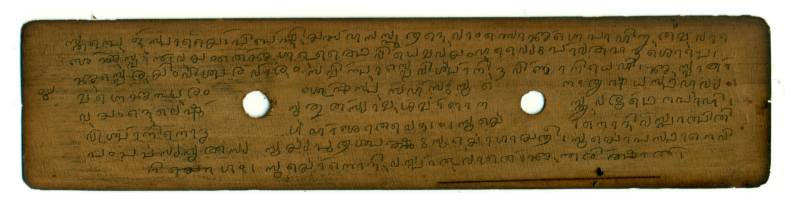

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = 'NAGRAJA BHAT SMVITM-20250202T164531Z-001/NAGRAJA BHAT SMVITM/TP2_S792/P-04-F.tif'
image = Image.open(image_path)

# Display the image in a large scale
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.show()

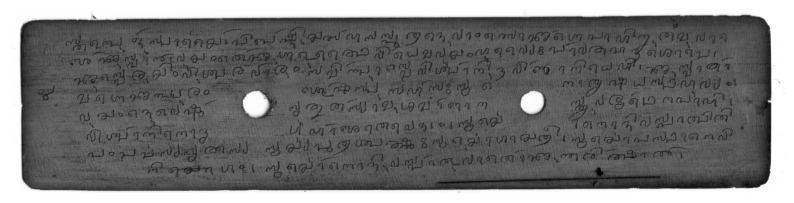

In [6]:
# Convert the image to grayscale
gray_image = image.convert('L')

# Display the grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(gray_image, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [8]:
!pip install plotly --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 7.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 7.3 MB/s eta 0:00:00 MB/s eta 0:00:01


In [25]:
import plotly.express as px

# Convert the grayscale image to a list of pixel values
pixel_values = list(gray_image.getdata())

# Create a histogram using plotly
fig = px.histogram(pixel_values, nbins=256, range_x=(0, 256), title='Histogram of Grayscale Image')
fig.update_layout(
    xaxis_title='Pixel Value',
    yaxis_title='Frequency',
    bargap=0.1
)
fig.show()

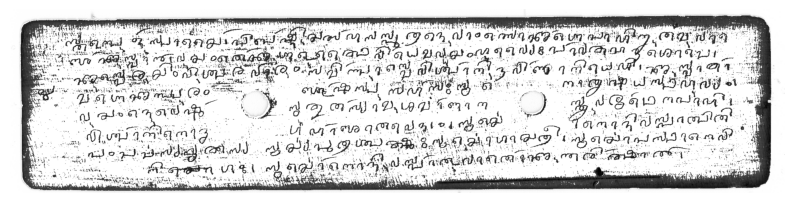

In [14]:
import numpy as np

# Convert the grayscale image to a numpy array
gray_array = np.array(gray_image)

# Set pixel values between 148 and 158 to 0
gray_array[(gray_array >= 75) & (gray_array <= 190)] = 255

# Convert the numpy array back to an image
modified_image = Image.fromarray(gray_array)

# Display the modified image
plt.figure(figsize=(10, 10))
plt.imshow(modified_image, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

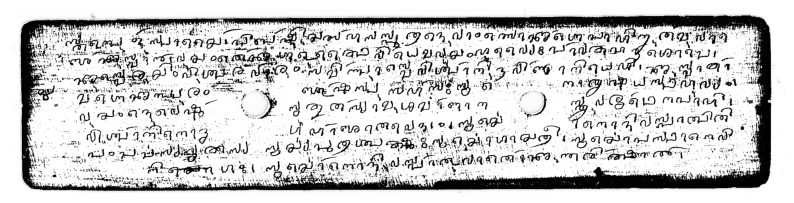

In [19]:
# Define a threshold for dark pixels
threshold = 93

# Reduce the pixel values that are below the threshold
gray_array[gray_array < threshold] = gray_array[gray_array < threshold] // 2

# Convert the numpy array back to an image
darker_image = Image.fromarray(gray_array)

# Display the modified image
plt.figure(figsize=(10, 10))
plt.imshow(darker_image, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [ ]:
# Convert the PIL image to a numpy array
image_np = np.array(image)

# Convert the image to grayscale using OpenCV
gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
denoised = cv2.fastNlMeansDenoising(gray, None, 10, 3, 21)

# Display the grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(denoised, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show() 

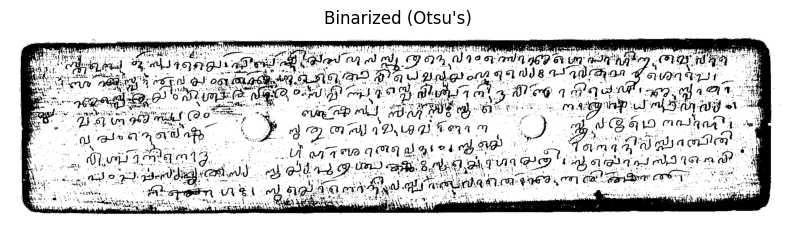

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Assume gray_array is your grayscale NumPy array
darker_image = Image.fromarray(gray_array)  # Convert NumPy array to PIL image

# Convert PIL image back to NumPy array (OpenCV format)
darker_np = np.array(darker_image)

# Apply Otsu's Binarization
_, binary = cv2.threshold(darker_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# # Display the images
# plt.figure(figsize=(10, 5))

# # Original Darker Image
# plt.subplot(1, 2, 1)
# plt.imshow(darker_np, cmap='gray')
# plt.title("Original Darker Image")
# plt.axis("off")

# Binarized Image
plt.figure(figsize=(10, 10))
plt.imshow(binary, cmap='gray')
plt.title("Binarized (Otsu's)")
plt.axis("off")

plt.show()

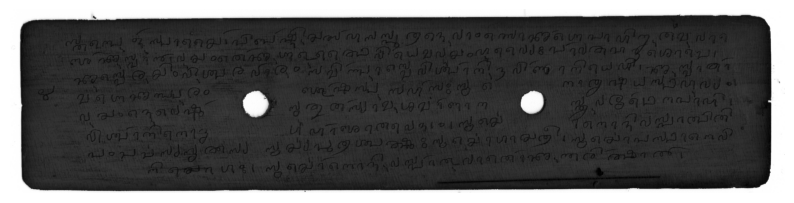

In [20]:
import cv2
import matplotlib.pyplot as plt

def preprocess_image(image_path: str) -> Image:
    # Open image and convert to grayscale
    image = Image.open(image_path).convert('L')
    gray_array = np.array(image)
    
    # Use Otsu's thresholding to automatically determine an optimal threshold value
    # The threshold value is ignored when using Otsu's method (hence passing 0)
    ret, binary = cv2.threshold(gray_array, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Now, using the computed threshold (ret), modify the image.
    # For example, darken pixels below the threshold to enhance contrast.
    # (You can adjust the multiplier/operation as needed for your application.)
    processed = np.where(gray_array < ret, gray_array // 2, gray_array)
    
    # Optionally, you might want to combine the modification with the binary mask.
    # For example, you could keep the foreground from the binary mask:
    # processed = np.where(binary == 255, gray_array, gray_array // 2)
    
    # Convert back to a PIL image and return
    processed_image = Image.fromarray(np.uint8(processed))
    return processed_image

darker_image = preprocess_image('NAGRAJA BHAT SMVITM-20250202T164531Z-001/NAGRAJA BHAT SMVITM/TP2_S792/P-04-F.tif')
plt.figure(figsize=(10, 10))
plt.imshow(darker_image, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

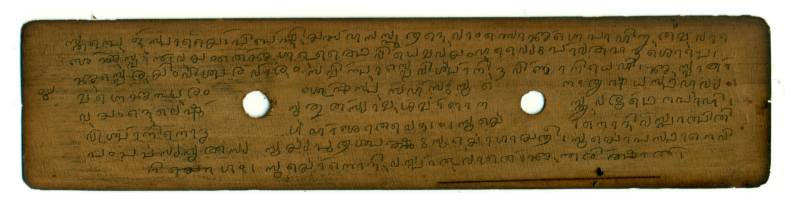

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = 'NAGRAJA BHAT SMVITM-20250202T164531Z-001/NAGRAJA BHAT SMVITM/TP2_S792/P-04-F.tif'
image = Image.open(image_path)

# Display the image in a large scale
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.show()

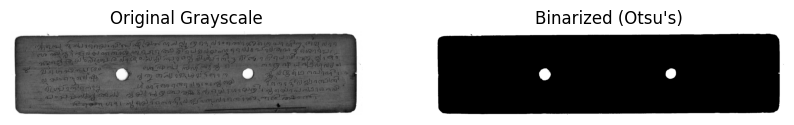

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def binarize_image(image_path, output_path):
    # Load the grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply Otsu's Thresholding
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Save the binarized image
    cv2.imwrite(output_path, binary)
    
    # Display the result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Grayscale")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(binary, cmap='gray')
    plt.title("Binarized (Otsu's)")
    plt.axis("off")
    
    plt.show()

binarize_image('NAGRAJA BHAT SMVITM-20250202T164531Z-001/NAGRAJA BHAT SMVITM/TP2_S792/P-04-F.tif','output.png')

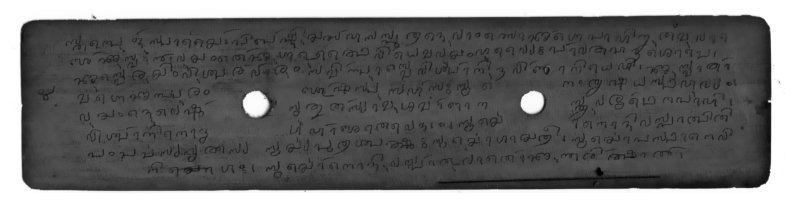

In [50]:
# Convert the PIL image to a numpy array
image_np = np.array(image)

# Convert the image to grayscale using OpenCV
gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
denoised = cv2.fastNlMeansDenoising(gray, None, 10, 3, 21)

# Display the grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(denoised, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show() 

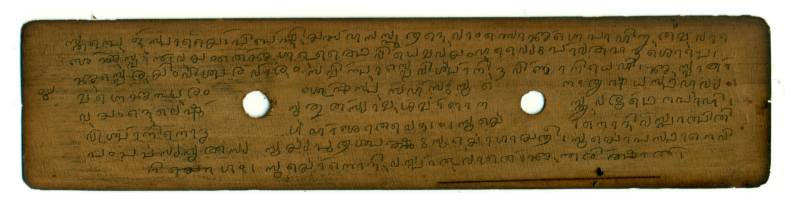

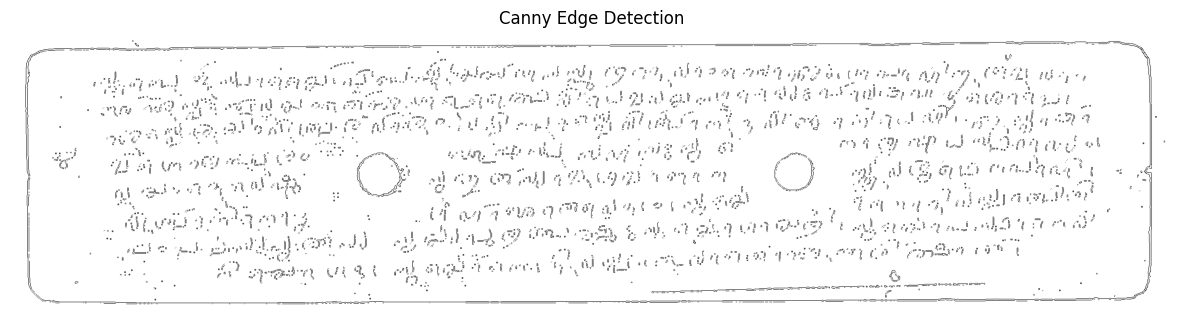

In [38]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image


# Load the image
image_path = 'NAGRAJA BHAT SMVITM-20250202T164531Z-001/NAGRAJA BHAT SMVITM/TP2_S792/P-04-F.tif'
image = Image.open(image_path)

# Display the image in a large scale
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.show()
# Assuming 'image' is your already loaded PIL image

# 1. Convert PIL image to NumPy array (ensure RGB order)
image_np = np.array(image)

# 2. Convert the RGB image to grayscale
# (If your image is in RGB, use COLOR_RGB2GRAY; if in BGR, use COLOR_BGR2GRAY)
gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

# 3. Denoise the grayscale image using fastNlMeansDenoising.
#    Parameters: h (filter strength), templateWindowSize, searchWindowSize.
denoised = cv2.fastNlMeansDenoising(gray, None, h=18, templateWindowSize=4, searchWindowSize=20)

# 4. Apply adaptive thresholding (binarization).
#    - Max value: 255
#    - Adaptive method: GAUSSIAN_C (accounts for local variations)
#    - Threshold type: THRESH_BINARY
#    - Block size: 11 (size of the neighborhood)
#    - Constant C: 2 (subtracted from the mean)
binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY, 11, 2)

# 5. (Optional) Enhance the binary image with morphological operations.
#    Here we use dilation to help connect broken parts of the text.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morphed = cv2.dilate(binary, kernel, iterations=1)

# 6. (Optional) Perform edge detection using Canny.
#    The parameters below are typical; adjust as needed.
edges = cv2.Canny(morphed, 100, 200)
edges = cv2.bitwise_not(edges)
# 7. Display the results for each step.
plt.figure(figsize=(15, 10))

plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.imshow(denoised, cmap='gray')
plt.title('Denoised')
plt.axis('off')

plt.imshow(binary, cmap='gray')
plt.title('Adaptive Threshold (Binarization)')
plt.axis('off')

plt.imshow(morphed, cmap='gray')
plt.title('Morphological Dilation')
plt.axis('off')

plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()


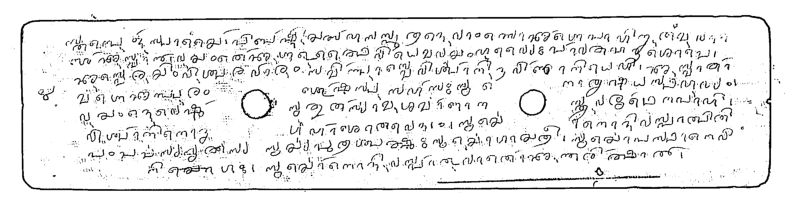

In [29]:
import numpy as np
import cv2
# Convert the PIL image to a numpy array
image_np = np.array(image)
# Convert the image to grayscale using OpenCV
gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
denoised = cv2.fastNlMeansDenoising(gray, None, 18, 4, 20)
binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY, 11, 2)
edges = cv2.Canny(binary, 50, 150)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
morphed_edges = cv2.dilate(edges, kernel, iterations=1)
# Display the grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(binary, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show() 

In [ ]:
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


In [ ]:
import numpy as np
import cv2
# Convert the PIL image to a numpy array
image_np = np.array(image)
# Convert the image to grayscale using OpenCV
gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
denoised = cv2.fastNlMeansDenoising(gray, None, 18, 4, 20)
binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY, 11, 2)
edges = cv2.Canny(binary, 50, 150)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morphed_edges = cv2.dilate(edges, kernel, iterations=1)
# Invert the colors back after dilation
morphed_edges = cv2.bitwise_not(morphed_edges)
# Display the grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(morphed_edges, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show() 